In [1]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import random

In [4]:
model_path = '../models/plant_model_best.keras'
dataset_dir = '../Data/PlantVillage'

#loading model
model = tf.keras.models.load_model(model_path)

Generating diagnostic report for 5 random leaves...



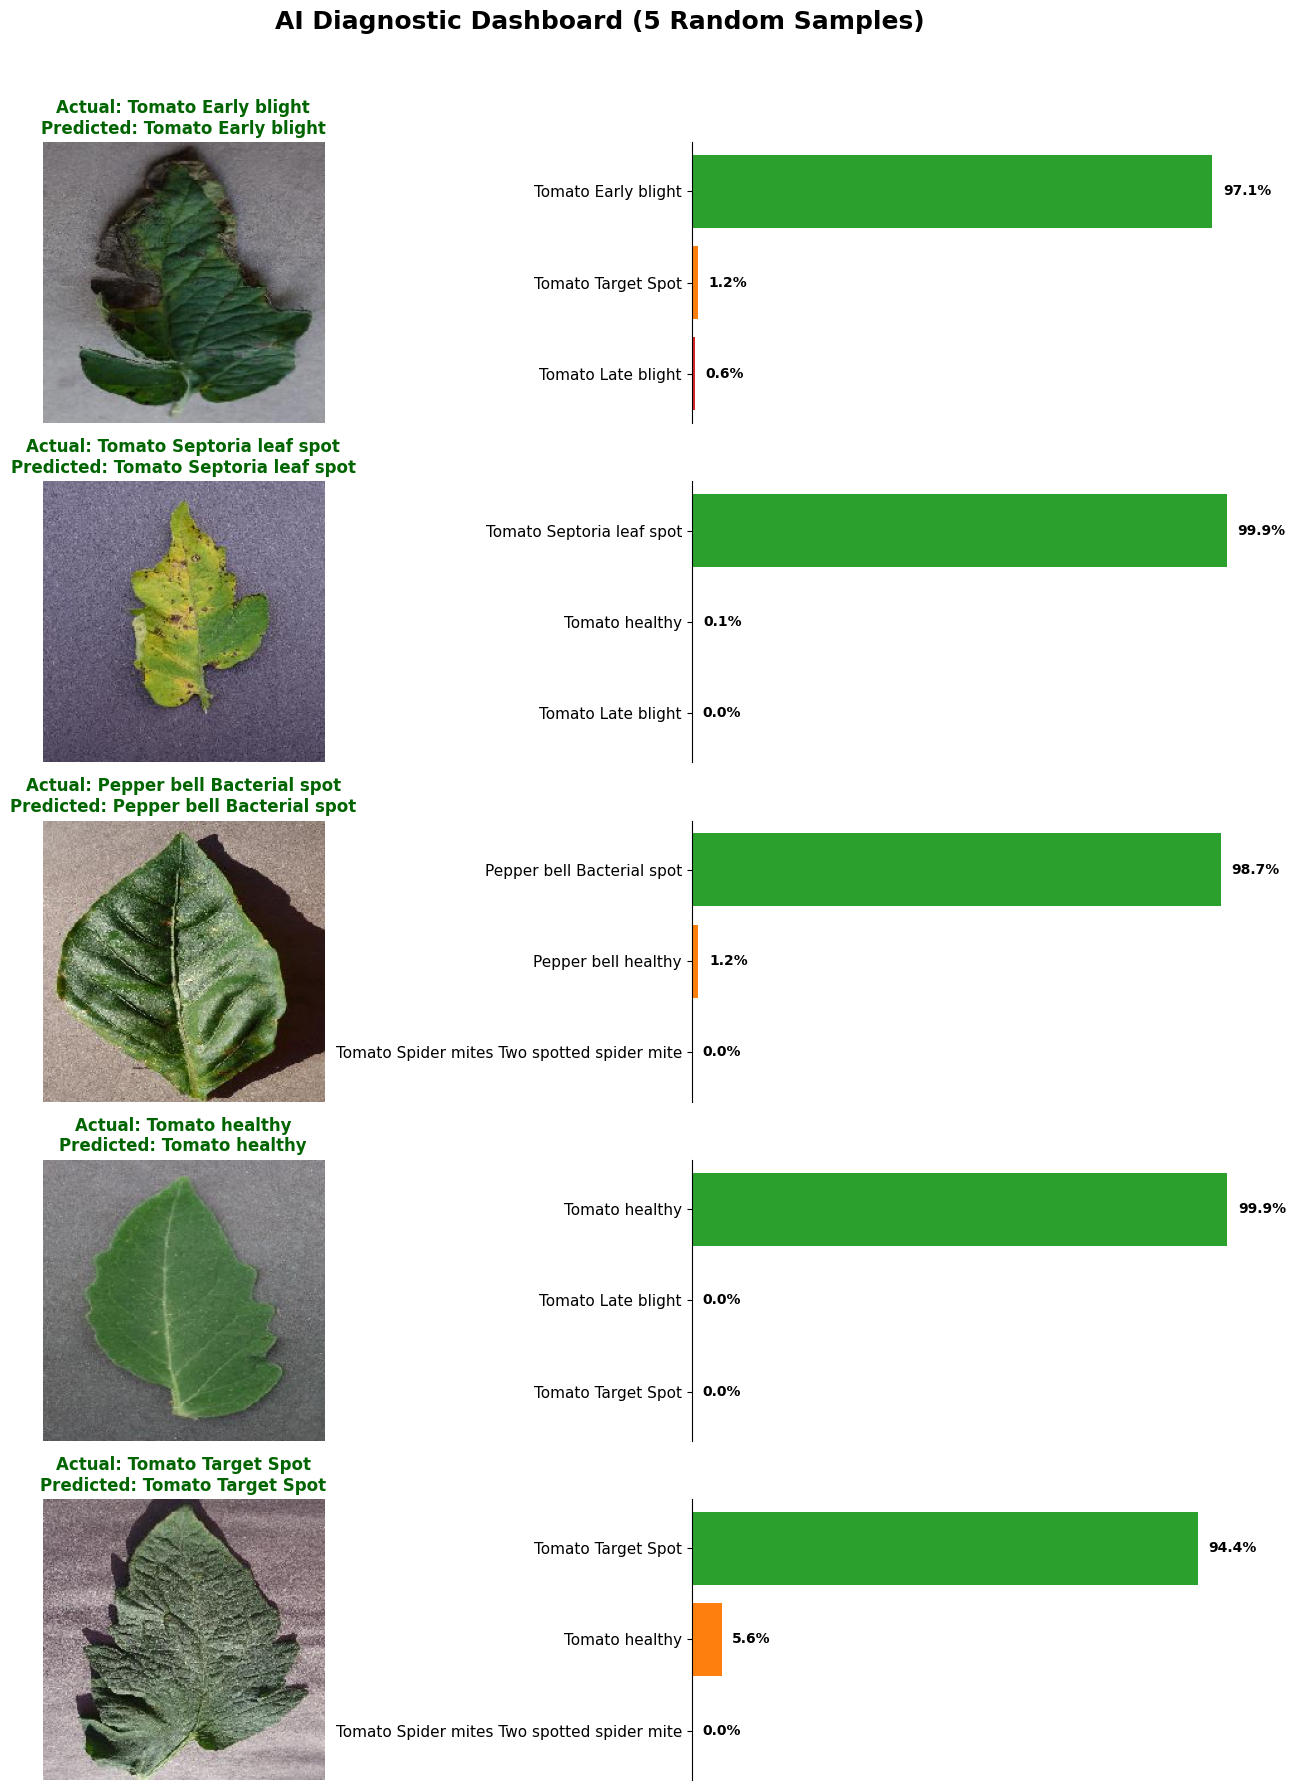

In [16]:
class_names = [
    'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 
    'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 
    'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 
    'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 
    'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 
    'Tomato_healthy'
]

# 2. Setup the Dashboard Canvas
NUM_IMAGES = 5
# Create a tall canvas: 5 rows, 2 columns
fig, axes = plt.subplots(NUM_IMAGES, 2, figsize=(14, 3.5 * NUM_IMAGES))
fig.suptitle("AI Diagnostic Dashboard (5 Random Samples)", fontsize=18, fontweight='bold', y=1.02)

print(f"Generating diagnostic report for {NUM_IMAGES} random leaves...\n")

for i in range(NUM_IMAGES):
    # --- Step A: Pick a Random Leaf ---
    random_class = random.choice(class_names)
    class_dir = os.path.join(dataset_dir, random_class)
    random_image_name = random.choice(os.listdir(class_dir))
    image_path = os.path.join(class_dir, random_image_name)

    # --- Step B: Preprocess ---
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0) 

    # --- Step C: Predict ---
    predictions = model.predict(img_batch, verbose=0)
    probabilities = predictions[0] 

    top_3_indices = np.argsort(probabilities)[-3:][::-1]
    top_3_classes = [class_names[j] for j in top_3_indices]
    top_3_probs = [probabilities[j] * 100 for j in top_3_indices]

    # --- Step D: Clean the text for readability ---
    clean_true = random_class.replace('___', ' ').replace('__', ' ').replace('_', ' ')
    clean_pred = top_3_classes[0].replace('___', ' ').replace('__', ' ').replace('_', ' ')
    clean_top_3 = [c.replace('___', ' ').replace('__', ' ').replace('_', ' ') for c in top_3_classes]

    # --- Step E: Plot Image (Left Column) ---
    ax_img = axes[i, 0]
    ax_img.imshow(img)
    
    # Logic for Green (Correct) vs Red (Incorrect) title
    title_color = 'darkgreen' if random_class == top_3_classes[0] else 'darkred'
    ax_img.set_title(f"Actual: {clean_true}\nPredicted: {clean_pred}", color=title_color, fontsize=12, fontweight='bold')
    ax_img.axis('off')

    # --- Step F: Plot Bar Chart (Right Column) ---
    ax_bar = axes[i, 1]
    y_pos = np.arange(len(top_3_classes))
    bars = ax_bar.barh(y_pos, top_3_probs, color=['#2ca02c', '#ff7f0e', '#d62728'])

    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(clean_top_3, fontsize=11)
    ax_bar.invert_yaxis() 
    ax_bar.set_xlim(0, 100)
    
    # Hide the borders of the chart to make it look cleaner
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.spines['bottom'].set_visible(False)
    ax_bar.set_xticks([]) # Remove bottom numbers since we put percentages on the bars

    # Add the exact percentages directly onto the bars
    for bar in bars:
        width = bar.get_width()
        ax_bar.text(width + 2, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()